Experiment 4: Classification with Bayesian Logistic Regression & SVM

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

For Bayesian Logistic Regression


In [14]:
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LogisticRegression

Load Dataset

In [15]:
df = pd.read_csv("dataset.csv")

Features and Target

In [17]:
X = df.drop("sex", axis=1)
y = df["sex"]
X = pd.get_dummies(X, drop_first=True)

Standardize features for SVM

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Bayseian Logistic Regression

In [21]:
blr_model = LogisticRegression(max_iter=1000)
blr_model.fit(X_train, y_train)
y_pred_blr = blr_model.predict(X_test)

SVM Classifier

In [22]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

Evaluation

--- Bayesian Logistic Regression Evaluation ---
Accuracy: 0.8067226890756303
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.18      0.28        49
           1       0.82      0.97      0.89       189

    accuracy                           0.81       238
   macro avg       0.71      0.58      0.58       238
weighted avg       0.78      0.81      0.76       238



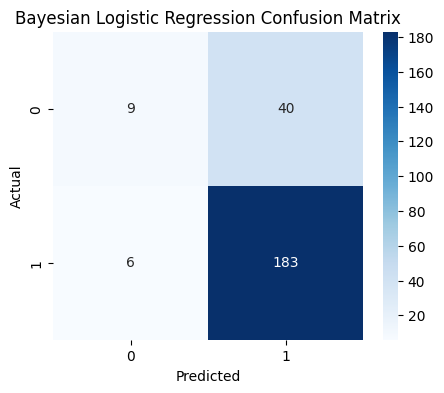

--- SVM Classifier Evaluation ---
Accuracy: 0.8403361344537815
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.35      0.47        49
           1       0.85      0.97      0.91       189

    accuracy                           0.84       238
   macro avg       0.80      0.66      0.69       238
weighted avg       0.83      0.84      0.82       238



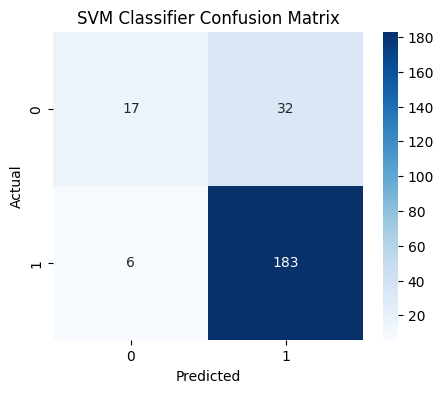

In [23]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(y_test, y_pred_blr, "Bayesian Logistic Regression")
evaluate_model(y_test, y_pred_svm, "SVM Classifier")